# Bootcamp Sesión 5 
### Estrategia Buy Bitcoin Baby

Octubre 2024

In [2]:
import os
from dotenv import load_dotenv
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
load_dotenv()


API_KEY = os.environ['FMP']

def get_full_price_data(ticker,  API_KEY):
    # Crear la URL dinámica con los parámetros de entrada
    url = f'https://financialmodelingprep.com/api/v3/historical-price-full/{ticker}?apikey={API_KEY}'
    
    # Hacer la solicitud GET a la API
    response = requests.get(url)
    
    # Comprobar si la respuesta fue exitosa (status code 200)
    if response.status_code == 200:
        # Convertir la respuesta a formato JSON
        data = response.json()
        df = pd.DataFrame(data['historical'])
        df = df.assign(ticker = f'{ticker}')
        return df
    else:
        # Si hubo un error, devolver el código de error
        print(f"Error: {response.status_code}")
        return None

        
# Calcular Métricas (Bandas de Bollinger)
def get_b_bands(data, n):
    """
    Calcular bandas de bollinger

    Parametros
    ----------
    data : pd.Series
        Precio de Cierre.
    n : int
        Número de velas.

    Regresa
    -------
    df : pd.DataFrame
        Bandas de Bollinger + Precio de Cierre df.

    """
    MA = pd.Series(pd.Series.rolling(data, n).mean())  
    MSD = pd.Series(pd.Series.rolling(data, n).std())  
    b1 = MA + (MSD*2) 
    B1 = pd.Series(b1, name = 'BB_' + str(n))  
    df = pd.concat([data,B1], axis=1)  
    b2 = MA - (MSD*2)  
    B2 = pd.Series(b2, name = 'Bb_' + str(n))  
    df = pd.concat([df,B2], axis=1)  
    df.reset_index(inplace=True,drop=True)
    return df


# Crear señales
def apply_mean_reverse(data, n):
    """
    Crear estrategia de regresion a la media con base en bandas de bollinger

    Parametros
    ----------
    data : pd.DataFrame
        Datos provenientes del exchange.
        
    n     : int
        Ventana de tiempo de las Bandas Bollinger.

    Regresa
    -------
    signal : bool
        Señal de la estrategia para comprar, vender o pasar.
    
    data  : pd.DataFrame
        Datos finales de la estrategia
    """
    
    # Calcular Bandas de Bollinger
    bbands = get_b_bands(data['close'], n)
    
    # Crear columnas Side (1, -1) y Side Ref (Ref Precio)
    bbands['side'] = np.nan 
    bbands['side_ref'] = np.nan
    
    # Crear mascara booleana de posiciones
    long_signals = (bbands['close'] <= bbands[f'Bb_{n}']) 
    short_signals = (bbands['close'] >= bbands[f'BB_{n}']) 
    
    # Asignar valores de Side y Sider Ref
    bbands.loc[long_signals, 'side_ref'] = bbands['close']
    bbands.loc[short_signals, 'side_ref'] = bbands['close']
    
    bbands.loc[long_signals, 'side'] = 1
    bbands.loc[short_signals, 'side'] = -1
    
    # Aplicar lógica para definir output
    if bbands['side'].iloc[-1] == 1:
        return True, bbands
    
    if bbands['side'].iloc[-1] == -1:
        return False, bbands
    else:
        return None, bbands
    

In [25]:
data = get_full_price_data('TSLA', API_KEY)

In [26]:
data['date'] = pd.to_datetime(data['date'])
data_s = data.set_index('date')['close'][::-1]

In [34]:
bbands = get_b_bands(data_s, 20)

In [28]:
bbands

,close,BB_20,Bb_20
0,17.46,NaN,NaN
1,17.13,NaN,NaN
2,16.90,NaN,NaN
3,17.04,NaN,NaN
4,16.98,NaN,NaN
...,...,...,...
1253,238.77,267.043259,222.440741
1254,217.80,268.705068,219.529932
1255,219.16,269.655361,217.817639
1256,219.57,270.543084,216.099916


<Axes: >

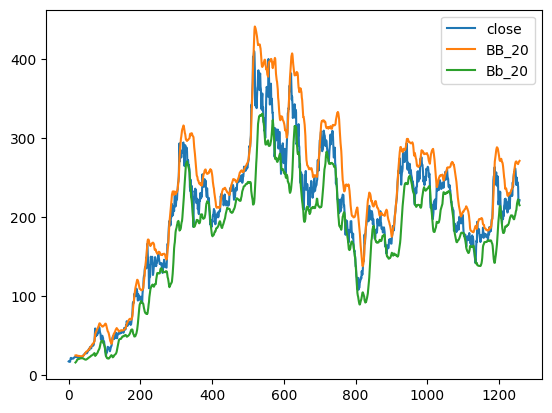

In [29]:
bbands.plot(kind='line')

In [37]:
app = apply_mean_reverse(bbands, 20)

In [38]:
app[]

(None,
        close       BB_20       Bb_20  side  side_ref
 0      17.46         NaN         NaN   NaN       NaN
 1      17.13         NaN         NaN   NaN       NaN
 2      16.90         NaN         NaN   NaN       NaN
 3      17.04         NaN         NaN   NaN       NaN
 4      16.98         NaN         NaN   NaN       NaN
 ...      ...         ...         ...   ...       ...
 1253  238.77  267.043259  222.440741   NaN       NaN
 1254  217.80  268.705068  219.529932   1.0     217.8
 1255  219.16  269.655361  217.817639   NaN       NaN
 1256  219.57  270.543084  216.099916   NaN       NaN
 1257  221.33  271.094912  214.961088   NaN       NaN
 
 [1258 rows x 5 columns])

<Axes: >

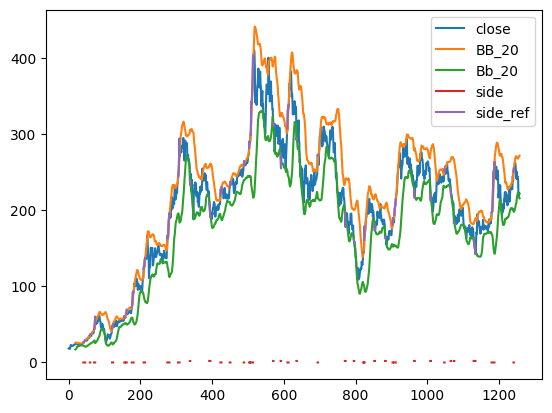

In [40]:
app[1].plot()